In [ ]:
!pip install boruta
!pip install lime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=8916c31ba6eabbf665ca2d2bdbe52c28fc6cf4187307bcc7065a928afcec0849
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc


from sklearn.feature_selection import RFE
from boruta import BorutaPy

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from lime import lime_tabular

# Load dataset
df = pd.read_csv("heart.csv")  # Replace with actual path

# Split features and target
X = df.drop("target", axis=1)
y = df["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- RFE ---
rfe = RFE(estimator=RandomForestClassifier(n_estimators=100, random_state=42), n_features_to_select=8)
rfe.fit(X_train_scaled, y_train)
rfe_features = X.columns[rfe.support_]
print("RFE Selected Features:", list(rfe_features))

# --- Boruta ---
boruta_selector = BorutaPy(RandomForestClassifier(n_estimators=100, random_state=42), n_estimators='auto', random_state=42)
boruta_selector.fit(X_train_scaled, y_train)
boruta_features = X.columns[boruta_selector.support_]
print("Boruta Selected Features:", list(boruta_features))

# --- RFE on Boruta ---
X_boruta = X[boruta_features]
X_train_boruta, X_test_boruta, y_train_boruta, y_test_boruta = train_test_split(X_boruta, y, test_size=0.2, stratify=y, random_state=42)
X_train_boruta_scaled = scaler.fit_transform(X_train_boruta)
X_test_boruta_scaled = scaler.transform(X_test_boruta)

rfe_final = RFE(estimator=RandomForestClassifier(n_estimators=100, random_state=42), n_features_to_select=6)
rfe_final.fit(X_train_boruta_scaled, y_train_boruta)
final_features = boruta_features[rfe_final.support_]
print("Final Features After RFE on Boruta:", list(final_features))

# Prepare final data
X_train_final = X_train[final_features]
X_test_final = X_test[final_features]
X_train_final_scaled = scaler.fit_transform(X_train_final)
X_test_final_scaled = scaler.transform(X_test_final)



RFE Selected Features: ['age', 'cp', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'thal']
Boruta Selected Features: ['age', 'cp', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Final Features After RFE on Boruta: ['age', 'cp', 'thalach', 'oldpeak', 'ca', 'thal']


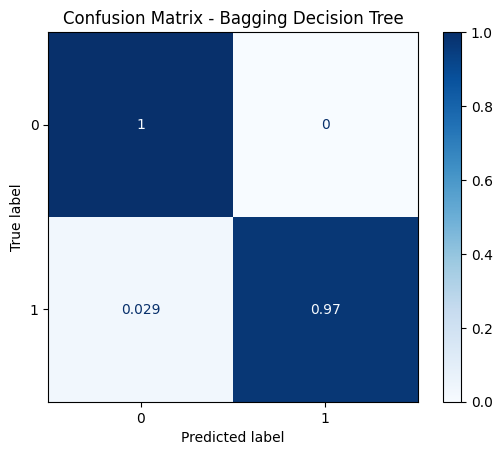

--- Bagging Decision Tree ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       100
           1       1.00      0.97      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

Accuracy: 0.9853658536585366
Precision: 1.0
Recall: 0.9714285714285714
F1 Score: 0.9855072463768116


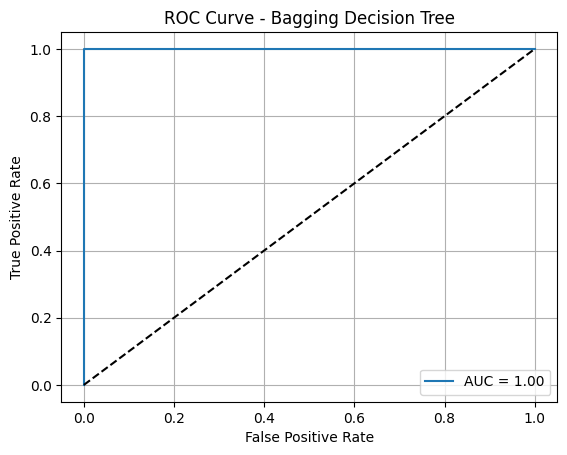

10-Fold CV Accuracy Scores: [0.97560976 0.98780488 0.97560976 0.98780488 1.         0.98780488
 1.         0.96341463 1.         0.98780488]
Mean CV Accuracy: 0.9865853658536586


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)
from sklearn.model_selection import cross_val_score
import shap
import lime
import lime.lime_tabular

# Model 1: Bagging Decision Tree
model_dt = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
model_dt.fit(X_train_final_scaled, y_train)
y_pred_dt = model_dt.predict(X_test_final_scaled)
y_proba_dt = model_dt.predict_proba(X_test_final_scaled)[:, 1]  # For AUC-ROC

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt, normalize='true')
ConfusionMatrixDisplay(cm_dt, display_labels=model_dt.classes_).plot(cmap='Blues')
plt.title("Confusion Matrix - Bagging Decision Tree")
plt.show()

# Classification Report
print("--- Bagging Decision Tree ---")
print(classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

# AUC-ROC
roc_auc = roc_auc_score(y_test, y_proba_dt)
fpr, tpr, _ = roc_curve(y_test, y_proba_dt)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Bagging Decision Tree")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 10-Fold Cross-Validation
cv_scores = cross_val_score(model_dt, X_train_final_scaled, y_train, cv=10, scoring='accuracy')
print("10-Fold CV Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# LIME Explanation
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_final_scaled,
    feature_names=X.columns.tolist(),
    class_names=["No Disease", "Disease"],
    mode="classification"
)

i = 5  # Pick any test instance to explain
exp = explainer.explain_instance(X_test_final_scaled[i], model_dt.predict_proba, num_features=10)
exp.show_in_notebook(show_table=True)



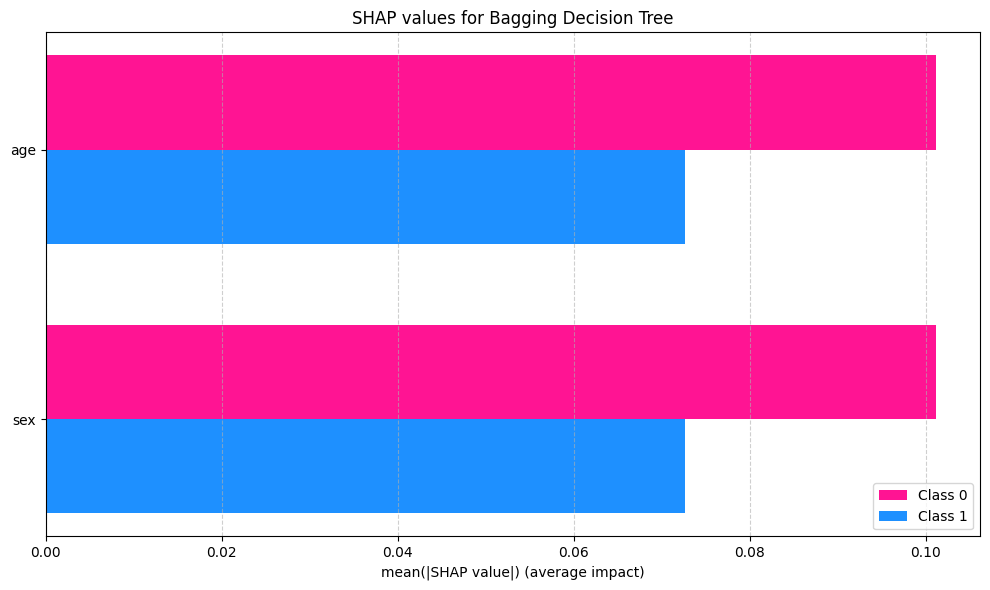

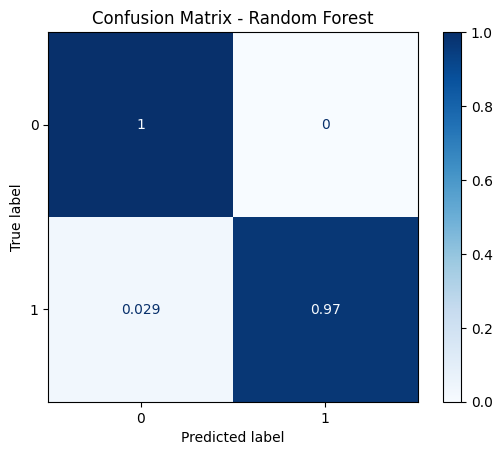

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       100
           1       1.00      0.97      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

Accuracy: 0.9853658536585366
Precision: 1.0
Recall: 0.9714285714285714
F1 Score: 0.9855072463768116


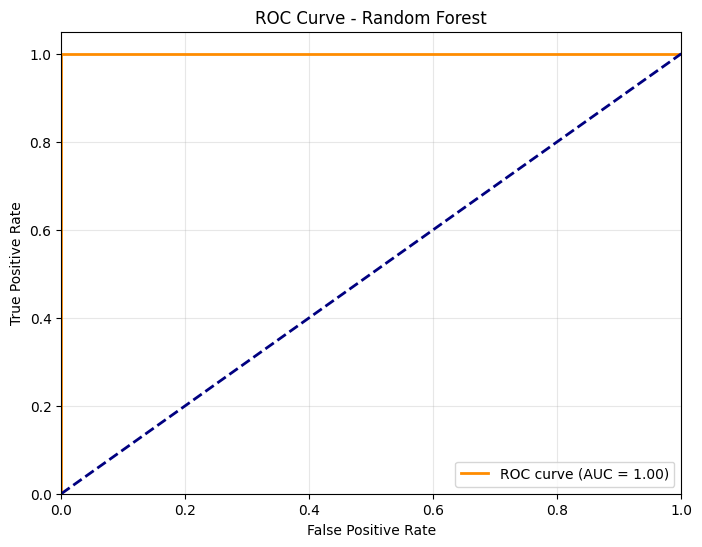

In [ ]:

# Random Forest
model_rf = RandomForestClassifier(n_estimators=50, random_state=42)
model_rf.fit(X_train_final_scaled, y_train)
y_pred_rf = model_rf.predict(X_test_final_scaled)
y_pred_proba_rf = model_rf.predict_proba(X_test_final_scaled)[:, 1]  # for ROC curve

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf, normalize='true')
ConfusionMatrixDisplay(cm_rf, display_labels=model_rf.classes_).plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Metrics
print("--- Random Forest ---")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

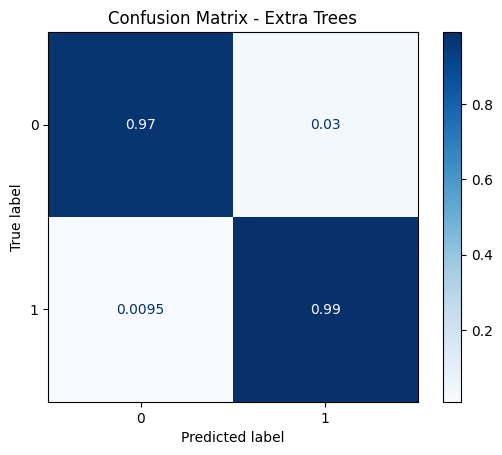

--- Extra Trees ---
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       100
           1       0.97      0.99      0.98       105

    accuracy                           0.98       205
   macro avg       0.98      0.98      0.98       205
weighted avg       0.98      0.98      0.98       205

Accuracy: 0.9804878048780488
Precision: 0.9719626168224299
Recall: 0.9904761904761905
F1 Score: 0.9811320754716981


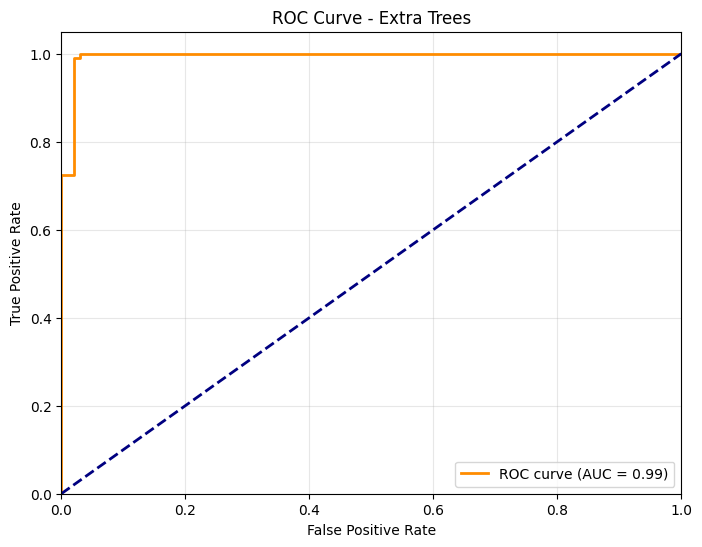

In [ ]:
model_et = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
model_et.fit(X_train_final_scaled, y_train)
y_pred_et = model_et.predict(X_test_final_scaled)
y_pred_proba_et = model_et.predict_proba(X_test_final_scaled)[:, 1]  # for ROC curve

# Confusion Matrix
cm_et = confusion_matrix(y_test, y_pred_et, normalize='true')
ConfusionMatrixDisplay(cm_et, display_labels=model_et.classes_).plot(cmap='Blues')
plt.title("Confusion Matrix - Extra Trees")
plt.show()

# Metrics
print("--- Extra Trees ---")
print(classification_report(y_test, y_pred_et))
print("Accuracy:", accuracy_score(y_test, y_pred_et))
print("Precision:", precision_score(y_test, y_pred_et))
print("Recall:", recall_score(y_test, y_pred_et))
print("F1 Score:", f1_score(y_test, y_pred_et))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_et)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Extra Trees')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

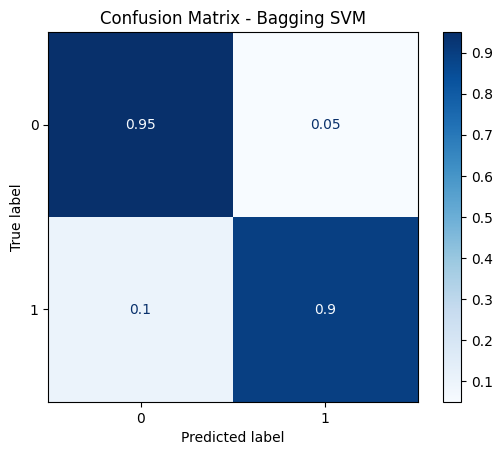

--- Bagging SVM ---
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       100
           1       0.95      0.90      0.92       105

    accuracy                           0.92       205
   macro avg       0.92      0.92      0.92       205
weighted avg       0.92      0.92      0.92       205

Accuracy: 0.9219512195121952
Precision: 0.9494949494949495
Recall: 0.8952380952380953
F1 Score: 0.9215686274509803


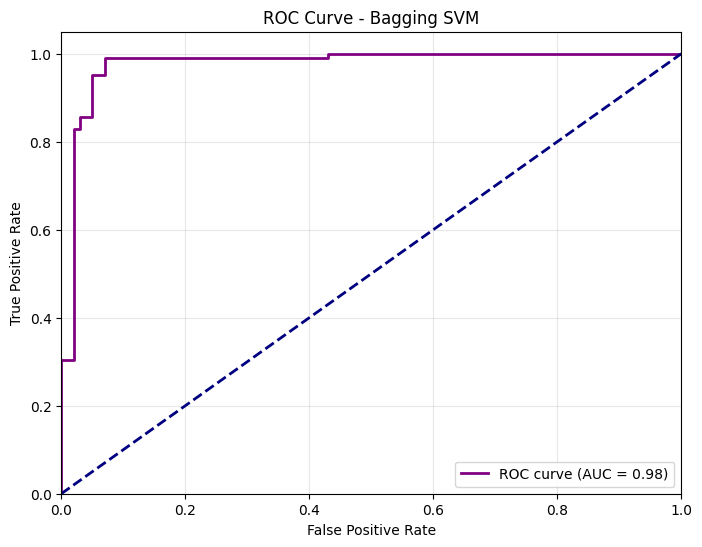

In [ ]:
# Bagging SVM
model_svm = BaggingClassifier(
    estimator=SVC(C=20, probability=True),
    n_estimators=10,
    random_state=42
)
model_svm.fit(X_train_final_scaled, y_train)
y_pred_svm = model_svm.predict(X_test_final_scaled)
y_pred_proba_svm = model_svm.predict_proba(X_test_final_scaled)[:, 1]  # for ROC curve

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm, normalize='true')
ConfusionMatrixDisplay(cm_svm, display_labels=model_svm.classes_).plot(cmap='Blues')
plt.title("Confusion Matrix - Bagging SVM")
plt.show()

# Metrics
print("--- Bagging SVM ---")
print(classification_report(y_test, y_pred_svm))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_svm)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='purple', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Bagging SVM')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

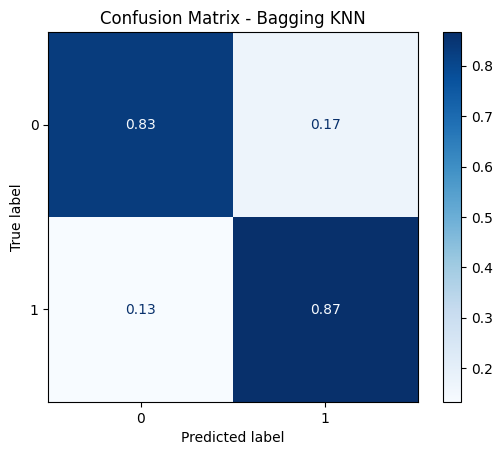

--- Bagging KNN ---
              precision    recall  f1-score   support

           0       0.86      0.83      0.84       100
           1       0.84      0.87      0.85       105

    accuracy                           0.85       205
   macro avg       0.85      0.85      0.85       205
weighted avg       0.85      0.85      0.85       205

Accuracy: 0.848780487804878
Precision: 0.8425925925925926
Recall: 0.8666666666666667
F1 Score: 0.8544600938967136


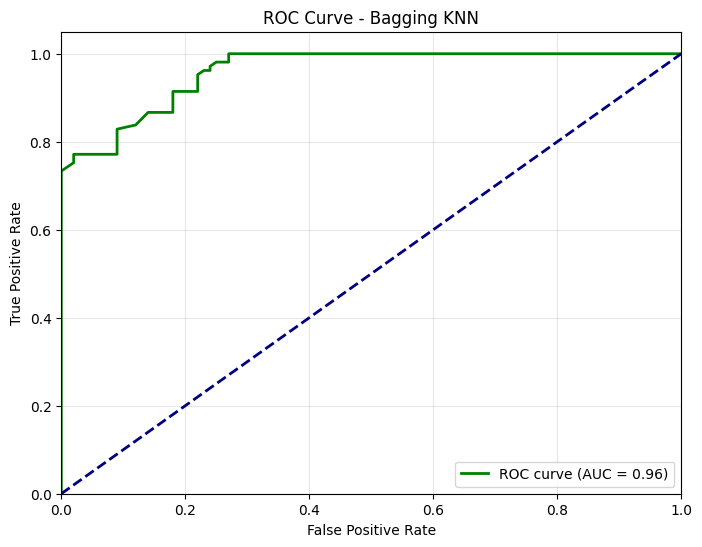

In [ ]:
# Bagging KNN
model_knn = BaggingClassifier(
    estimator=KNeighborsClassifier(),
    n_estimators=10,
    random_state=42
)
model_knn.fit(X_train_final_scaled, y_train)
y_pred_knn = model_knn.predict(X_test_final_scaled)
y_pred_proba_knn = model_knn.predict_proba(X_test_final_scaled)[:, 1]  # for ROC curve

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn, normalize='true')
ConfusionMatrixDisplay(cm_knn, display_labels=model_knn.classes_).plot(cmap='Blues')
plt.title("Confusion Matrix - Bagging KNN")
plt.show()

# Metrics
print("--- Bagging KNN ---")
print(classification_report(y_test, y_pred_knn))
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_knn)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Bagging KNN')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

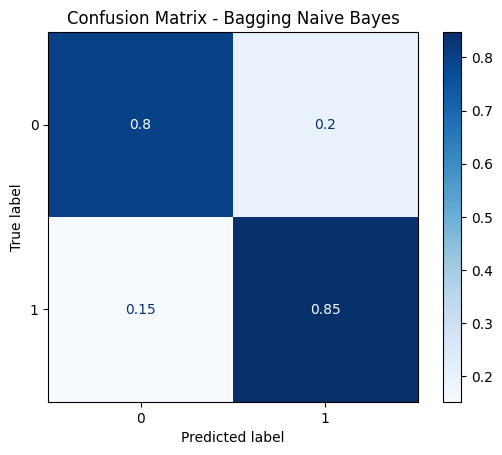

--- Bagging Naive Bayes ---
              precision    recall  f1-score   support

           0       0.83      0.80      0.82       100
           1       0.82      0.85      0.83       105

    accuracy                           0.82       205
   macro avg       0.82      0.82      0.82       205
weighted avg       0.82      0.82      0.82       205

Accuracy: 0.824390243902439
Precision: 0.8165137614678899
Recall: 0.8476190476190476
F1 Score: 0.8317757009345794


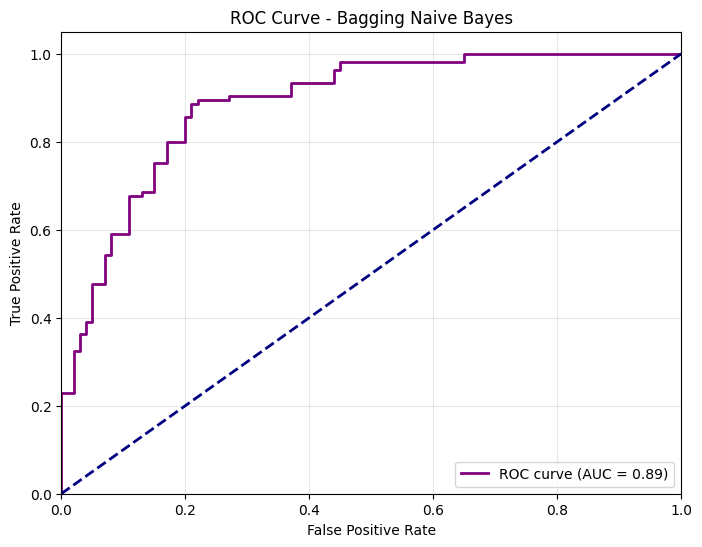

In [ ]:
model_nb = BaggingClassifier(
    estimator=GaussianNB(),
    n_estimators=10,
    random_state=42
)
model_nb.fit(X_train_final_scaled, y_train)
y_pred_nb = model_nb.predict(X_test_final_scaled)
y_pred_proba_nb = model_nb.predict_proba(X_test_final_scaled)[:, 1]  # for ROC curve

# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb, normalize='true')
ConfusionMatrixDisplay(cm_nb, display_labels=model_nb.classes_).plot(cmap='Blues')
plt.title("Confusion Matrix - Bagging Naive Bayes")
plt.show()

# Metrics
print("--- Bagging Naive Bayes ---")
print(classification_report(y_test, y_pred_nb))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_nb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='purple', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Bagging Naive Bayes')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


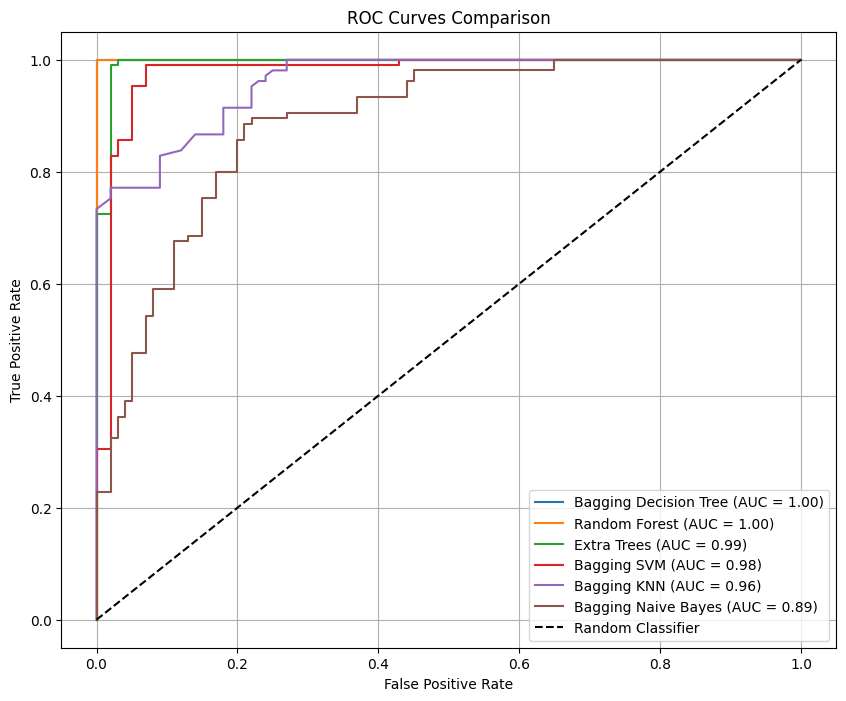

In [ ]:
# Predict probabilities for each model
y_proba_dt = model_dt.predict_proba(X_test_final_scaled)[:, 1]
y_proba_rf = model_rf.predict_proba(X_test_final_scaled)[:, 1]
y_proba_et = model_et.predict_proba(X_test_final_scaled)[:, 1]
y_proba_svm = model_svm.predict_proba(X_test_final_scaled)[:, 1]
y_proba_knn = model_knn.predict_proba(X_test_final_scaled)[:, 1]
y_proba_nb = model_nb.predict_proba(X_test_final_scaled)[:, 1]

# Calculate ROC curve and AUC for each model
models = {
    "Bagging Decision Tree": y_proba_dt,
    "Random Forest": y_proba_rf,
    "Extra Trees": y_proba_et,
    "Bagging SVM": y_proba_svm,
    "Bagging KNN": y_proba_knn,
    "Bagging Naive Bayes": y_proba_nb,
}

plt.figure(figsize=(10, 8))

for model_name, y_proba in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.2f})")

# Plot random line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

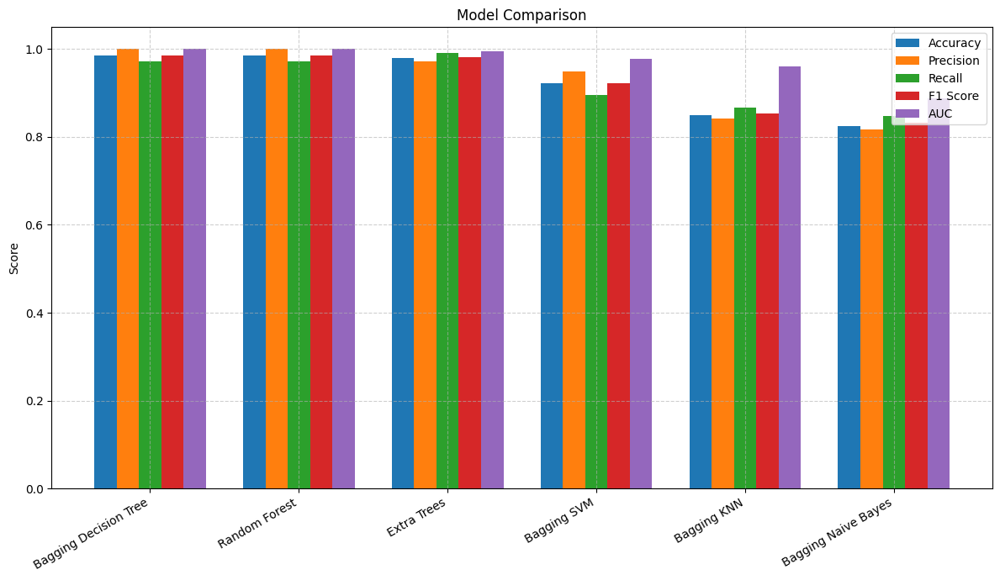

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Collect metrics
model_names = [
    "Bagging Decision Tree",
    "Random Forest",
    "Extra Trees",
    "Bagging SVM",
    "Bagging KNN",
    "Bagging Naive Bayes"
]

y_preds = [
    y_pred_dt, y_pred_rf, y_pred_et, y_pred_svm, y_pred_knn, y_pred_nb
]

y_probas = [
    y_proba_dt, y_proba_rf, y_proba_et, y_proba_svm, y_proba_knn, y_proba_nb
]

# Calculate metrics
accuracy = [accuracy_score(y_test, y_pred) for y_pred in y_preds]
precision = [precision_score(y_test, y_pred) for y_pred in y_preds]
recall = [recall_score(y_test, y_pred) for y_pred in y_preds]
f1 = [f1_score(y_test, y_pred) for y_pred in y_preds]
auc = [roc_auc_score(y_test, y_proba) for y_proba in y_probas]

# Bar chart
x = np.arange(len(model_names))
width = 0.15

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - 2*width, accuracy, width, label='Accuracy')
rects2 = ax.bar(x - width, precision, width, label='Precision')
rects3 = ax.bar(x, recall, width, label='Recall')
rects4 = ax.bar(x + width, f1, width, label='F1 Score')
rects5 = ax.bar(x + 2*width, auc, width, label='AUC')

ax.set_ylabel('Score')
ax.set_title('Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha="right")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


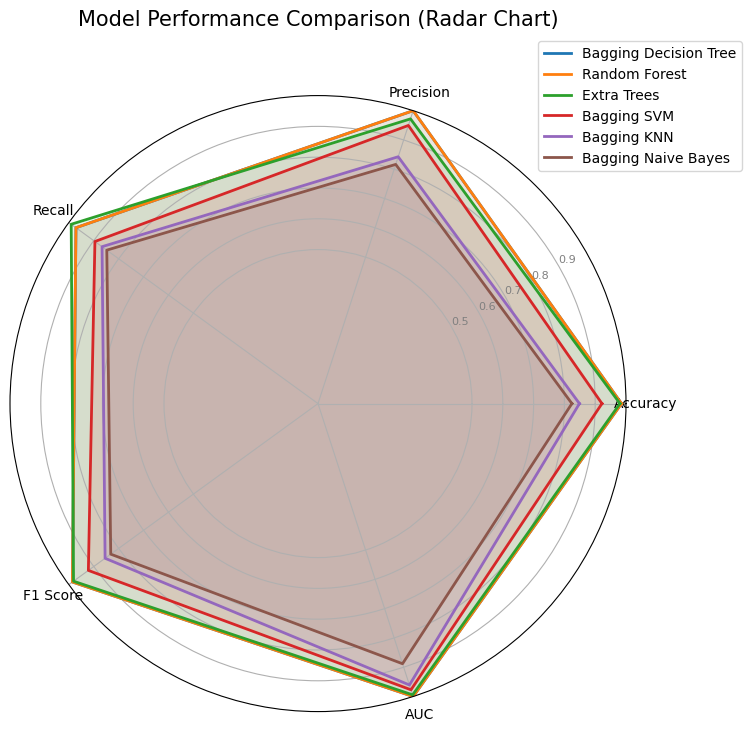

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from math import pi

# Collect metrics
model_names = [
    "Bagging Decision Tree",
    "Random Forest",
    "Extra Trees",
    "Bagging SVM",
    "Bagging KNN",
    "Bagging Naive Bayes"
]

# Metrics lists
y_preds = [y_pred_dt, y_pred_rf, y_pred_et, y_pred_svm, y_pred_knn, y_pred_nb]
y_probas = [y_proba_dt, y_proba_rf, y_proba_et, y_proba_svm, y_proba_knn, y_proba_nb]

# Calculate metrics
accuracy = [accuracy_score(y_test, y_pred) for y_pred in y_preds]
precision = [precision_score(y_test, y_pred) for y_pred in y_preds]
recall = [recall_score(y_test, y_pred) for y_pred in y_preds]
f1 = [f1_score(y_test, y_pred) for y_pred in y_preds]
auc = [roc_auc_score(y_test, y_proba) for y_proba in y_probas]

# Combine into one structure
metrics = np.array([accuracy, precision, recall, f1, auc])

# Number of variables we're plotting
categories = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']
N = len(categories)

# What will be the angle of each axis in the plot?
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # complete the loop

# Plot
fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

for idx, model in enumerate(model_names):
    values = metrics[:, idx].tolist()
    values += values[:1]  # complete the loop
    ax.plot(angles, values, linewidth=2, label=model)
    ax.fill(angles, values, alpha=0.1)

# Add labels
plt.xticks(angles[:-1], categories)
ax.set_rlabel_position(30)
plt.yticks([0.5, 0.6, 0.7, 0.8, 0.9], ["0.5","0.6","0.7","0.8","0.9"], color="grey", size=8)
plt.ylim(0,1)

# Title and legend
plt.title('Model Performance Comparison (Radar Chart)', size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

plt.show()


In [ ]:
explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_final_scaled,
    feature_names=list(final_features),
    class_names=['No Disease', 'Disease'],
    mode='classification'
)

i = 1  # Pick sample
exp_dt = explainer.explain_instance(X_test_final_scaled[i], model_dt.predict_proba, num_features=len(final_features))
exp_dt.show_in_notebook(show_table=True, show_all=False)




In [ ]:
exp_rf = explainer.explain_instance(X_test_final_scaled[i], model_rf.predict_proba, num_features=len(final_features))
exp_rf.show_in_notebook(show_table=True, show_all=False)



In [ ]:
exp_et = explainer.explain_instance(X_test_final_scaled[i], model_et.predict_proba, num_features=len(final_features))
exp_et.show_in_notebook(show_table=True, show_all=False)



In [ ]:
exp_svm = explainer.explain_instance(X_test_final_scaled[i], model_svm.predict_proba, num_features=len(final_features))
exp_svm.show_in_notebook(show_table=True, show_all=False)



In [ ]:
exp_knn = explainer.explain_instance(X_test_final_scaled[i], model_knn.predict_proba, num_features=len(final_features))
exp_knn.show_in_notebook(show_table=True, show_all=False)



In [ ]:
exp_nb = explainer.explain_instance(X_test_final_scaled[i], model_nb.predict_proba, num_features=len(final_features))
exp_nb.show_in_notebook(show_table=True, show_all=False)

shap

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 2 with shape (2,) and arg 3 with shape (13,).

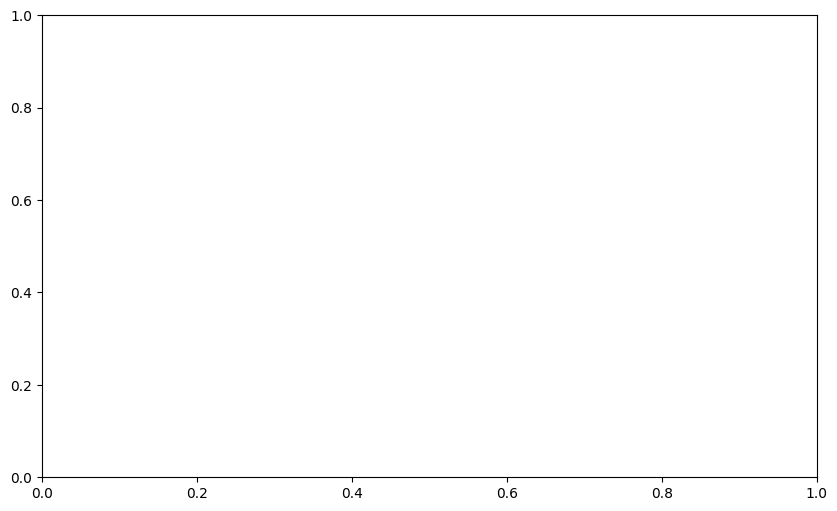

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# 1. For Tree models (use shap.TreeExplainer)
# explainer = shap.TreeExplainer(model_dt)   # model_name = model_dt, model_rf, model_et
# shap_values = explainer.shap_values(X_test_final_scaled)

explainer = shap.TreeExplainer(model_dt.estimators_[0])  # Take one tree inside
shap_values = explainer.shap_values(X_test_final_scaled)


# 2. For Kernel models (SVM, KNN, NB) use KernelExplainer
# (only if it's not tree model)
# explainer = shap.KernelExplainer(model_name.predict_proba, shap.sample(X_train_final_scaled, 100))
# shap_values = explainer.shap_values(X_test_final_scaled[:50])

# 3. Plot
feature_names = X.columns.tolist()
mean_shap_class0 = np.abs(shap_values[0]).mean(axis=0)
mean_shap_class1 = np.abs(shap_values[1]).mean(axis=0)

x = np.arange(len(feature_names))
width = 0.35  # Width of bars

fig, ax = plt.subplots(figsize=(10, 6))
bars0 = ax.barh(x - width/2, mean_shap_class0, width, label='Class 0', color='red')
bars1 = ax.barh(x + width/2, mean_shap_class1, width, label='Class 1', color='blue')

ax.set(yticks=x, yticklabels=feature_names)
ax.invert_yaxis()  # Labels read top-to-bottom
ax.set_xlabel('mean(|SHAP value|) (average impact on model output magnitude)')
ax.set_title('SHAP values Comparison')
ax.legend()
plt.grid(True)
plt.show()


In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

def plot_shap(model, X_train, X_test, feature_names, model_name="Model"):
    # Focus only on the probability of class 1 (positive class)
    def model_predict(X):
        return model.predict_proba(X)[:, 1]

    explainer = shap.KernelExplainer(model_predict, shap.sample(X_train, 50))  # Speed up with sample
    shap_values = explainer.shap_values(X_test, nsamples=100)

    mean_shap = np.abs(shap_values).mean(axis=0)

    # Sort by importance
    indices = np.argsort(mean_shap)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.barh(range(len(mean_shap)), mean_shap[indices], color="skyblue")
    plt.yticks(range(len(mean_shap)), np.array(feature_names)[indices])
    plt.xlabel("Mean Absolute SHAP Value")
    plt.title(f"SHAP Feature Importance - {model_name}")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()


  0%|          | 0/205 [00:00<?, ?it/s]

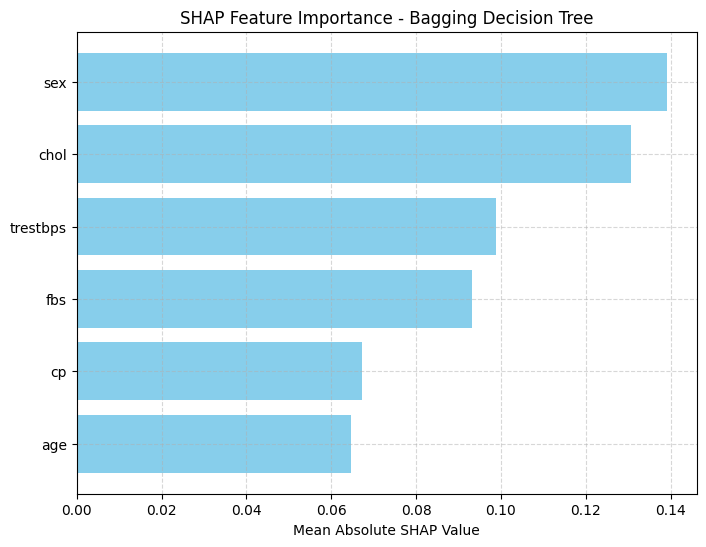

In [ ]:
plot_shap(model_dt, X_train_final_scaled, X_test_final_scaled, X.columns.tolist(), model_name="Bagging Decision Tree")


  0%|          | 0/205 [00:00<?, ?it/s]

  0%|          | 0/205 [00:00<?, ?it/s]

  0%|          | 0/205 [00:00<?, ?it/s]

  0%|          | 0/205 [00:00<?, ?it/s]

  0%|          | 0/205 [00:00<?, ?it/s]

  0%|          | 0/205 [00:00<?, ?it/s]

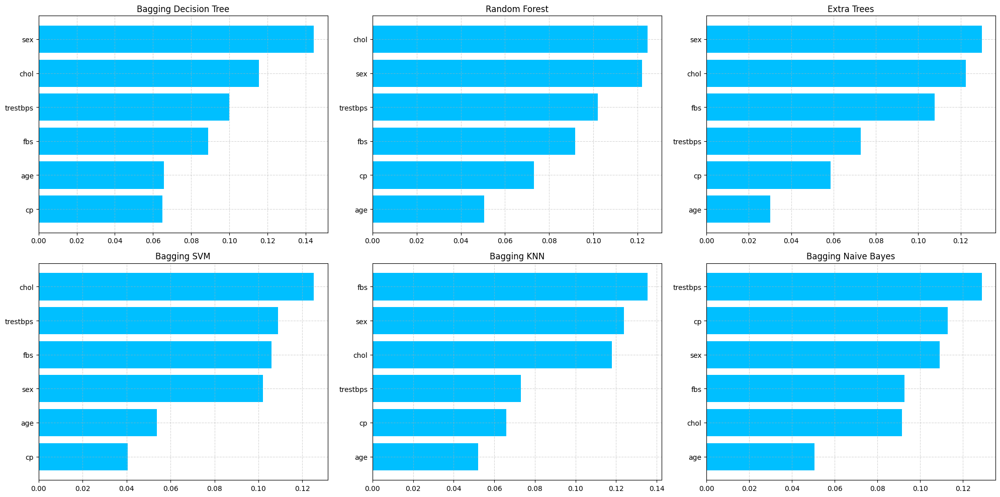

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Function to plot SHAP for one model
def plot_shap_summary(model, X_train, X_test, feature_names, model_name="Model"):
    def model_predict(X):
        return model.predict_proba(X)[:, 1]  # Focus on positive class probability

    explainer = shap.KernelExplainer(model_predict, shap.sample(X_train, 50, random_state=42))
    shap_values = explainer.shap_values(X_test, nsamples=100)

    mean_shap = np.abs(shap_values).mean(axis=0)
    indices = np.argsort(mean_shap)

    return mean_shap, indices, model_name

# List of all your models and names
models = [
    (model_dt, "Bagging Decision Tree"),
    (model_rf, "Random Forest"),
    (model_et, "Extra Trees"),
    (model_svm, "Bagging SVM"),
    (model_knn, "Bagging KNN"),
    (model_nb, "Bagging Naive Bayes")
]

# Collect SHAP values for all models
shap_data = []
for model, name in models:
    mean_shap, indices, model_name = plot_shap_summary(model, X_train_final_scaled, X_test_final_scaled, X.columns.tolist(), model_name=name)
    shap_data.append((mean_shap, indices, model_name))

# Plotting all together
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for idx, (mean_shap, indices, model_name) in enumerate(shap_data):
    ax = axes[idx]
    ax.barh(range(len(mean_shap)), mean_shap[indices], color="deepskyblue")
    ax.set_yticks(range(len(mean_shap)))
    ax.set_yticklabels(np.array(X.columns.tolist())[indices])
    ax.set_title(model_name)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()
